# March Madness 2026: Data-Driven Final Four Analysis

A composite analytical pipeline using KenPom efficiency metrics, NET rankings,
quad records, Monte Carlo bracket simulation, and seed-constraint optimization.

**Seed constraint:** Sum of seeds >= 15 | **Method:** Composite model -> 10K Monte Carlo sims -> Brute-force optimization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
import requests
from bs4 import BeautifulSoup
import re, os, time, warnings
from itertools import product as iterproduct
from collections import defaultdict

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = [12, 8]

REGION_COLORS = {'East': '#1f77b4', 'South': '#d62728', 'West': '#2ca02c', 'Midwest': '#ff7f0e'}
SCRAPED_DIR = 'scraped_data'
os.makedirs(SCRAPED_DIR, exist_ok=True)
print('Setup complete.')

Setup complete.


## 2. Load KenPom Data

Parse team efficiency ratings, offensive/defensive metrics, and strength of schedule.

In [2]:
col_names = ['Rk', 'Team', 'Conf', 'W_L', 'NetRtg', 'ORtg', 'DRtg', 'AdjT', 'Luck',
             'SOS_NetRtg', 'SOS_ORtg', 'SOS_DRtg', 'NCSOS_NetRtg']
kenpom = pd.read_csv('kenpom.csv', skiprows=2, header=None, names=col_names)

# Parse seed from team name (e.g., "Duke 1" -> ("Duke", 1))
def parse_team_seed(team_str):
    m = re.match(r'(.+?)\s+(\d+)$', str(team_str))
    if m:
        return m.group(1).strip(), int(m.group(2))
    return str(team_str).strip(), None

kenpom[['TeamName', 'KP_Seed']] = kenpom['Team'].apply(
    lambda x: pd.Series(parse_team_seed(x))
)

for col in ['Rk', 'NetRtg', 'ORtg', 'DRtg', 'AdjT', 'Luck',
            'SOS_NetRtg', 'SOS_ORtg', 'SOS_DRtg', 'NCSOS_NetRtg']:
    kenpom[col] = pd.to_numeric(kenpom[col], errors='coerce')
kenpom['Rk'] = kenpom['Rk'].astype(int)
kenpom['KP_Seed'] = kenpom['KP_Seed'].astype(int)

print(f'Loaded {len(kenpom)} teams from KenPom')
kenpom[['Rk', 'TeamName', 'KP_Seed', 'Conf', 'W_L', 'NetRtg', 'ORtg', 'DRtg', 'SOS_NetRtg']].head(10)

Loaded 68 teams from KenPom


,Rk,TeamName,KP_Seed,Conf,W_L,NetRtg,ORtg,DRtg,SOS_NetRtg
0,1,Duke,1,ACC,32-2,38.90,127.9,89.1,14.29
1,2,Arizona,1,B12,32-2,37.62,127.7,90.0,14.94
2,3,Michigan,1,B10,31-3,37.58,126.6,89.0,16.65
3,4,Florida,1,SEC,26-7,33.78,125.5,91.8,16.01
4,5,Houston,2,B12,28-6,33.39,124.8,91.5,13.56
5,6,Iowa St.,2,B12,27-7,32.38,123.8,91.4,12.40
6,7,Illinois,3,B10,24-8,32.09,131.2,99.1,13.64
7,8,Purdue,2,B10,27-8,31.19,131.6,100.4,15.88
8,9,Michigan St.,3,B10,25-7,28.30,123.0,94.7,13.69
9,10,Gonzaga,3,WCC,30-3,28.10,122.0,93.9,5.90


## 3. Load Bracket Data & Merge

Resolve play-in games, normalize team names across sources, and merge bracket structure with KenPom data.

In [3]:
bracket = pd.read_csv('bracket.csv')

# KenPom name -> standard/bracket name
KENPOM_TO_STD = {
    'Michigan St.': 'Michigan State', 'Iowa St.': 'Iowa State',
    'Ohio St.': 'Ohio State', 'Connecticut': 'UConn',
    'Utah St.': 'Utah State', 'Miami FL': 'Miami (FL)',
    'N.C. State': 'NC State', 'North Dakota St.': 'North Dakota State',
    'Wright St.': 'Wright State', 'Kennesaw St.': 'Kennesaw State',
    'Miami OH': 'Miami (OH)', 'Tennessee St.': 'Tennessee State',
    'LIU': 'Long Island University', 'Queens': 'Queens (NC)',
}
kenpom['StdName'] = kenpom['TeamName'].replace(KENPOM_TO_STD)

# Play-in resolutions (winner projected by KenPom rank)
PLAYIN = {
    'NC State/Texas': ('NC State', 11),       # KP #34 > #37
    'SMU/Miami (OH)': ('SMU', 11),            # KP #42 > #93
    'Howard/UMBC': ('UMBC', 16),              # KP #188 > #204
    'Lehigh/Prairie View A&M': ('Lehigh', 16) # KP #284 > #288
}

rows = []
for _, row in bracket.iterrows():
    r = row.to_dict()
    for tcol, scol in [('TeamA', 'SeedA'), ('TeamB', 'SeedB')]:
        if r[tcol] in PLAYIN:
            r[tcol], r[scol] = PLAYIN[r[tcol]]
    rows.append(r)
bracket = pd.DataFrame(rows)

print('Play-in projections:')
for matchup, (winner, seed) in PLAYIN.items():
    print(f'  {matchup} -> {winner} (seed {seed})')

# Build flat team list from bracket
team_rows = []
for _, row in bracket.iterrows():
    team_rows.append({'StdName': row['TeamA'], 'Region': row['Region'],
                      'Seed': int(row['SeedA']), 'GameID': row['GameID']})
    team_rows.append({'StdName': row['TeamB'], 'Region': row['Region'],
                      'Seed': int(row['SeedB']), 'GameID': row['GameID']})
bracket_teams = pd.DataFrame(team_rows).drop_duplicates(subset='StdName')

# Merge with KenPom
df = bracket_teams.merge(
    kenpom.drop(columns=['Team', 'TeamName', 'KP_Seed']),
    on='StdName', how='left'
)

missing = df[df['NetRtg'].isna()]['StdName'].tolist()
if missing:
    print(f'\nWARNING: No KenPom data for: {missing}')
else:
    print(f'\nAll {len(df)} tournament teams matched successfully.')

df.sort_values('Rk')[['StdName', 'Region', 'Seed', 'Rk', 'NetRtg', 'ORtg', 'DRtg', 'SOS_NetRtg']].head(16)

Play-in projections:
  NC State/Texas -> NC State (seed 11)
  SMU/Miami (OH) -> SMU (seed 11)
  Howard/UMBC -> UMBC (seed 16)
  Lehigh/Prairie View A&M -> Lehigh (seed 16)

All 64 tournament teams matched successfully.


,StdName,Region,Seed,Rk,NetRtg,ORtg,DRtg,SOS_NetRtg
0,Duke,East,1,1,38.90,127.9,89.1,14.29
32,Arizona,West,1,2,37.62,127.7,90.0,14.94
48,Michigan,Midwest,1,3,37.58,126.6,89.0,16.65
16,Florida,South,1,4,33.78,125.5,91.8,16.01
30,Houston,South,2,5,33.39,124.8,91.5,13.56
62,Iowa State,Midwest,2,6,32.38,123.8,91.4,12.40
26,Illinois,South,3,7,32.09,131.2,99.1,13.64
46,Purdue,West,2,8,31.19,131.6,100.4,15.88
10,Michigan State,East,3,9,28.30,123.0,94.7,13.69
42,Gonzaga,West,3,10,28.10,122.0,93.9,5.90


## 4. Scrape NET Rankings & Quad Records

Scrape Warren Nolan for NET rankings and per-team quad records (Q1-Q4 win-loss).
Results are cached to `scraped_data/` so re-runs skip scraping.

**Fallback:** If scraping fails, KenPom rank proxies for NET rank and composite weights are redistributed.

In [4]:
NET_CACHE = os.path.join(SCRAPED_DIR, 'net_rankings.csv')
QUAD_CACHE = os.path.join(SCRAPED_DIR, 'quad_records.csv')
HEADERS = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}

has_net = False
has_quad = False

# --- NET Rankings ---
if os.path.exists(NET_CACHE):
    net_df = pd.read_csv(NET_CACHE)
    has_net = True
    print(f'Loaded cached NET rankings ({len(net_df)} teams)')
else:
    print('Scraping NET rankings from Warren Nolan...')
    try:
        resp = requests.get('https://www.warrennolan.com/basketball/2026/net',
                           headers=HEADERS, timeout=15)
        resp.raise_for_status()
        soup = BeautifulSoup(resp.text, 'lxml')

        tables = soup.find_all('table')
        net_data = []

        for table in tables:
            trs = table.find_all('tr')
            if len(trs) < 20:
                continue
            for tr in trs[1:]:
                cells_html = tr.find_all(['td', 'th'])
                if len(cells_html) >= 2:
                    rank_text = cells_html[0].get_text(strip=True)
                    team_text = cells_html[1].get_text(strip=True)
                    try:
                        rank = int(rank_text)
                        if 1 <= rank <= 400 and team_text:
                            net_data.append({'NET_Team': team_text, 'NET_Rank': rank})
                    except ValueError:
                        continue
            if net_data:
                break

        if net_data:
            net_df = pd.DataFrame(net_data)
            net_df.to_csv(NET_CACHE, index=False)
            has_net = True
            print(f'Scraped {len(net_df)} NET rankings')
        else:
            print('Could not parse NET rankings table')
    except Exception as e:
        print(f'NET scraping failed: {e}')

# --- Quad Records ---
if os.path.exists(QUAD_CACHE):
    quad_df = pd.read_csv(QUAD_CACHE)
    has_quad = True
    print(f'Loaded cached quad records ({len(quad_df)} teams)')
else:
    WN_SLUGS = {
        'Duke': 'Duke', 'Arizona': 'Arizona', 'Michigan': 'Michigan',
        'Florida': 'Florida', 'Houston': 'Houston', 'Iowa State': 'Iowa-State',
        'Illinois': 'Illinois', 'Purdue': 'Purdue', 'Michigan State': 'Michigan-State',
        'Gonzaga': 'Gonzaga', 'UConn': 'Connecticut', 'Vanderbilt': 'Vanderbilt',
        'Virginia': 'Virginia', 'Nebraska': 'Nebraska', 'Arkansas': 'Arkansas',
        'Tennessee': 'Tennessee', "St. John's": 'St-Johns', 'Alabama': 'Alabama',
        'Louisville': 'Louisville', 'Texas Tech': 'Texas-Tech', 'Kansas': 'Kansas',
        'Wisconsin': 'Wisconsin', 'BYU': 'BYU', "Saint Mary's": 'Saint-Marys',
        'Iowa': 'Iowa', 'Ohio State': 'Ohio-State', 'UCLA': 'UCLA',
        'Kentucky': 'Kentucky', 'North Carolina': 'North-Carolina',
        'Utah State': 'Utah-State', 'Miami (FL)': 'Miami-FL', 'Georgia': 'Georgia',
        'Villanova': 'Villanova', 'NC State': 'NC-State', 'Santa Clara': 'Santa-Clara',
        'Clemson': 'Clemson', 'Texas A&M': 'Texas-AM', 'Saint Louis': 'Saint-Louis',
        'SMU': 'SMU', 'TCU': 'TCU', 'VCU': 'VCU', 'South Florida': 'South-Florida',
        'Missouri': 'Missouri', 'UCF': 'UCF', 'Akron': 'Akron', 'McNeese': 'McNeese',
        'Northern Iowa': 'Northern-Iowa', 'Hofstra': 'Hofstra',
        'High Point': 'High-Point', 'Cal Baptist': 'Cal-Baptist', 'Hawaii': 'Hawaii',
        'North Dakota State': 'North-Dakota-State', 'Wright State': 'Wright-State',
        'Troy': 'Troy', 'Idaho': 'Idaho', 'Penn': 'Penn',
        'Kennesaw State': 'Kennesaw-State', 'Queens (NC)': 'Queens',
        'Tennessee State': 'Tennessee-State', 'UMBC': 'UMBC', 'Furman': 'Furman',
        'Siena': 'Siena', 'Howard': 'Howard', 'Long Island University': 'LIU',
        'Lehigh': 'Lehigh',
    }

    print('Scraping quad records from Warren Nolan team sheets...')
    quad_data = []
    teams_to_scrape = df['StdName'].tolist()

    for i, team in enumerate(teams_to_scrape):
        slug = WN_SLUGS.get(team, team.replace(' ', '-').replace("'", '').replace('(', '').replace(')', ''))
        urls = [
            f'https://www.warrennolan.com/basketball/2026/team-sheet?team={slug}',
            f'https://www.warrennolan.com/basketball/2026/team-sheet/{slug}',
        ]

        for url in urls:
            try:
                resp = requests.get(url, headers=HEADERS, timeout=10)
                if resp.status_code != 200:
                    continue
                soup = BeautifulSoup(resp.text, 'lxml')
                text = soup.get_text()

                q1_match = re.search(r'Q(?:uad\s*)?1[:\s]+(\d+)-(\d+)', text, re.IGNORECASE)
                q2_match = re.search(r'Q(?:uad\s*)?2[:\s]+(\d+)-(\d+)', text, re.IGNORECASE)

                if q1_match:
                    q1_w, q1_l = int(q1_match.group(1)), int(q1_match.group(2))
                    q2_w = int(q2_match.group(1)) if q2_match else 0
                    q2_l = int(q2_match.group(2)) if q2_match else 0
                    q1_pct = q1_w / (q1_w + q1_l) if (q1_w + q1_l) > 0 else 0
                    q1q2_total = q1_w + q2_w + q1_l + q2_l
                    q1q2_pct = (q1_w + q2_w) / q1q2_total if q1q2_total > 0 else 0
                    quad_data.append({
                        'StdName': team, 'Q1_W': q1_w, 'Q1_L': q1_l,
                        'Q1_WinPct': round(q1_pct, 3),
                        'Q2_W': q2_w, 'Q2_L': q2_l,
                        'Q1Q2_WinPct': round(q1q2_pct, 3)
                    })
                    break
            except Exception:
                continue

        if (i + 1) % 10 == 0:
            print(f'  Processed {i + 1}/{len(teams_to_scrape)} teams...')
        time.sleep(0.5)

    if quad_data:
        quad_df = pd.DataFrame(quad_data)
        quad_df.to_csv(QUAD_CACHE, index=False)
        has_quad = True
        print(f'Scraped quad records for {len(quad_df)} teams')
    else:
        print('Quad record scraping returned no data - using fallback weights')

# --- Merge scraped data ---
if has_net:
    net_map = {}
    for std_name in df['StdName'].values:
        for _, net_row in net_df.iterrows():
            net_name = str(net_row['NET_Team'])
            if (std_name.lower() == net_name.lower() or
                std_name.lower() in net_name.lower() or
                net_name.lower() in std_name.lower()):
                net_map[std_name] = net_row['NET_Rank']
                break
    df['NET_Rank'] = df['StdName'].map(net_map)
    matched = df['NET_Rank'].notna().sum()
    print(f'Matched {matched}/{len(df)} teams with NET rankings')
    df['NET_Rank'] = df['NET_Rank'].fillna(df['Rk'])
else:
    print('Using KenPom rank as proxy for NET rank')
    df['NET_Rank'] = df['Rk'].astype(float)

if has_quad:
    df = df.merge(quad_df, on='StdName', how='left')
    df['Q1_WinPct'] = df['Q1_WinPct'].fillna(0)
    df['Q1Q2_WinPct'] = df['Q1Q2_WinPct'].fillna(0)
else:
    df['Q1_WinPct'] = np.nan
    df['Q1Q2_WinPct'] = np.nan

print(f'\nData ready: {len(df)} teams, metrics: {"full" if (has_net and has_quad) else "partial (fallback weights)"}')

Scraping NET rankings from Warren Nolan...


Could not parse NET rankings table
Loaded cached quad records (64 teams)
Using KenPom rank as proxy for NET rank

Data ready: 64 teams, metrics: partial (fallback weights)


## 5. Composite Scoring Model

Normalize each metric to 0-100 (min-max across tournament field), then compute a weighted composite score.

| Metric | Weight (full) | Weight (fallback) |
|--------|:---:|:---:|
| KenPom NetRtg | 0.25 | 0.35 |
| KenPom ORtg | 0.15 | 0.20 |
| KenPom DRtg (inverted) | 0.10 | 0.10 |
| SOS NetRtg | 0.10 | 0.10 |
| NET Rank (inverted) | 0.15 | 0.25 |
| Q1 Win % | 0.15 | -- |
| Q1+Q2 Win % | 0.10 | -- |

**Tiebreaker:** When composite scores are within 1 point, rank by ORtg.

In [5]:
def normalize_0_100(series, invert=False):
    s = series.copy()
    if invert:
        s = -s
    rng = s.max() - s.min()
    if rng == 0:
        return pd.Series(50.0, index=series.index)
    return ((s - s.min()) / rng * 100)

df['n_NetRtg'] = normalize_0_100(df['NetRtg'])
df['n_ORtg'] = normalize_0_100(df['ORtg'])
df['n_DRtg'] = normalize_0_100(df['DRtg'], invert=True)
df['n_SOS'] = normalize_0_100(df['SOS_NetRtg'])
df['n_NET'] = normalize_0_100(df['NET_Rank'], invert=True)

if has_quad and df['Q1_WinPct'].notna().any() and df['Q1_WinPct'].sum() > 0:
    df['n_Q1'] = normalize_0_100(df['Q1_WinPct'].fillna(0))
    df['n_Q1Q2'] = normalize_0_100(df['Q1Q2_WinPct'].fillna(0))
    df['Composite'] = (
        0.25 * df['n_NetRtg'] + 0.15 * df['n_ORtg'] + 0.10 * df['n_DRtg'] +
        0.10 * df['n_SOS'] + 0.15 * df['n_NET'] +
        0.15 * df['n_Q1'] + 0.10 * df['n_Q1Q2']
    )
    weight_scheme = 'Full (with quad records)'
else:
    df['Composite'] = (
        0.35 * df['n_NetRtg'] + 0.20 * df['n_ORtg'] + 0.10 * df['n_DRtg'] +
        0.10 * df['n_SOS'] + 0.25 * df['n_NET']
    )
    weight_scheme = 'Fallback (no quad records)'

# Sort with ORtg tiebreaker
df = df.sort_values(['Composite', 'ORtg'], ascending=[False, False]).reset_index(drop=True)
df['CompRank'] = range(1, len(df) + 1)
df['ORtg_Rank'] = df['ORtg'].rank(ascending=False).astype(int)
df['DRtg_Rank'] = df['DRtg'].rank(ascending=True).astype(int)

print(f'Composite scoring: {weight_scheme}\n')
print('Top 20 by Composite Score:')
df[['CompRank', 'StdName', 'Region', 'Seed', 'Composite', 'NetRtg', 'ORtg', 'DRtg', 'NET_Rank']].head(20)

Composite scoring: Full (with quad records)

Top 20 by Composite Score:


,CompRank,StdName,Region,Seed,Composite,NetRtg,ORtg,DRtg,NET_Rank
0,1,Duke,East,1,95.497466,38.90,127.9,89.1,1.0
1,2,Arizona,West,1,94.623435,37.62,127.7,90.0,2.0
2,3,Michigan,Midwest,1,93.252612,37.58,126.6,89.0,3.0
3,4,Florida,South,1,84.644488,33.78,125.5,91.8,4.0
4,5,Houston,South,2,82.069879,33.39,124.8,91.5,5.0
5,6,Purdue,West,2,81.307209,31.19,131.6,100.4,8.0
6,7,UConn,East,2,80.176387,27.85,122.0,94.1,11.0
7,8,Gonzaga,West,3,79.578768,28.10,122.0,93.9,10.0
8,9,Iowa State,Midwest,2,79.512143,32.38,123.8,91.4,6.0
9,10,Illinois,South,3,78.624326,32.09,131.2,99.1,7.0


## 6. Round-by-Round Monte Carlo Bracket Simulation

Simulate each regional bracket **10,000 times** using KenPom efficiency differentials converted to win probabilities via logistic function.

- **Win probability:** `P(A) = 1 / (1 + 10^(-(NetRtg_A - NetRtg_B) / 22))`
- Naturally accounts for bracket path difficulty and variance

In [6]:
N_SIMS = 10_000

def win_prob(net_a, net_b):
    margin = (net_a - net_b) / 2
    return 1 / (1 + 10 ** (-margin / 11))

REGION_SEED = {'East': 0, 'South': 1, 'West': 2, 'Midwest': 3}

def simulate_region(region, df, bracket, n_sims=N_SIMS, seed=42):
    rng = np.random.default_rng(seed + REGION_SEED[region])
    games = bracket[bracket['Region'] == region].sort_values('GameID')

    # Build R64 matchups as lightweight dicts
    matchups = []
    for _, g in games.iterrows():
        a = df[df['StdName'] == g['TeamA']].iloc[0]
        b = df[df['StdName'] == g['TeamB']].iloc[0]
        matchups.append((
            {'name': a['StdName'], 'net': float(a['NetRtg']), 'seed': int(a['Seed'])},
            {'name': b['StdName'], 'net': float(b['NetRtg']), 'seed': int(b['Seed'])}
        ))

    counts = defaultdict(int)

    for _ in range(n_sims):
        # R64
        w = []
        for a, b in matchups:
            p = win_prob(a['net'], b['net'])
            w.append(a if rng.random() < p else b)
        # R32
        r32 = []
        for i in range(0, 8, 2):
            p = win_prob(w[i]['net'], w[i+1]['net'])
            r32.append(w[i] if rng.random() < p else w[i+1])
        # Sweet 16
        s16 = []
        for i in range(0, 4, 2):
            p = win_prob(r32[i]['net'], r32[i+1]['net'])
            s16.append(r32[i] if rng.random() < p else r32[i+1])
        # Elite 8
        p = win_prob(s16[0]['net'], s16[1]['net'])
        champ = s16[0] if rng.random() < p else s16[1]
        counts[champ['name']] += 1

    return {t: c / n_sims for t, c in sorted(counts.items(), key=lambda x: -x[1])}

print(f'Running {N_SIMS:,} Monte Carlo simulations per region...\n')
sim_results = {}
for region in ['East', 'South', 'West', 'Midwest']:
    sim_results[region] = simulate_region(region, df, bracket)
    top = list(sim_results[region].items())[:5]
    print(f'{region} Region:')
    for team, prob in top:
        seed = df[df['StdName'] == team]['Seed'].values[0]
        print(f'  ({seed}) {team}: {prob:.1%}')
    print()

# Add FF probability to main dataframe
ff_map = {team: prob for region_res in sim_results.values() for team, prob in region_res.items()}
df['FF_Prob'] = df['StdName'].map(ff_map).fillna(0)

Running 10,000 Monte Carlo simulations per region...

East Region:
  (1) Duke: 54.6%
  (2) UConn: 12.8%
  (3) Michigan State: 11.8%
  (5) St. John's: 5.9%
  (4) Kansas: 5.1%



South Region:


  (1) Florida: 30.3%
  (2) Houston: 26.0%
  (3) Illinois: 22.3%
  (5) Vanderbilt: 8.2%
  (4) Nebraska: 7.2%



West Region:
  (1) Arizona: 48.9%
  (2) Purdue: 21.7%
  (3) Gonzaga: 11.3%
  (4) Arkansas: 7.4%
  (5) Wisconsin: 3.8%

Midwest Region:


  (1) Michigan: 47.8%
  (2) Iowa State: 24.1%
  (3) Virginia: 8.2%
  (4) Alabama: 5.9%
  (5) Texas Tech: 4.9%



## 7. Seed Constraint Optimization

Brute-force all 4-tuples (one per region, top 5 candidates each) to find the configuration
that maximizes probability-weighted composite score while satisfying seed sum >= 15.

In [7]:
# Top 5 candidates per region by FF probability
candidates = {}
for region in ['East', 'South', 'West', 'Midwest']:
    region_df = df[df['Region'] == region].nlargest(5, 'FF_Prob')
    candidates[region] = region_df[['StdName', 'Seed', 'Composite', 'FF_Prob']].to_dict('records')

# Brute-force all valid combos
configs = []
for e, s, w, m in iterproduct(candidates['East'], candidates['South'],
                               candidates['West'], candidates['Midwest']):
    seed_sum = e['Seed'] + s['Seed'] + w['Seed'] + m['Seed']
    if seed_sum >= 15:
        total_comp = e['Composite'] + s['Composite'] + w['Composite'] + m['Composite']
        weighted = (e['Composite'] * e['FF_Prob'] + s['Composite'] * s['FF_Prob'] +
                    w['Composite'] * w['FF_Prob'] + m['Composite'] * m['FF_Prob'])
        configs.append({
            'East': e['StdName'], 'South': s['StdName'],
            'West': w['StdName'], 'Midwest': m['StdName'],
            'Seeds': f"{e['Seed']}+{s['Seed']}+{w['Seed']}+{m['Seed']}={seed_sum}",
            'Seed_Sum': seed_sum, 'Total_Composite': round(total_comp, 1),
            'Weighted_Score': round(weighted, 1),
            'E_Seed': e['Seed'], 'S_Seed': s['Seed'],
            'W_Seed': w['Seed'], 'M_Seed': m['Seed'],
        })

configs_df = pd.DataFrame(configs).sort_values('Weighted_Score', ascending=False)
print(f'Found {len(configs_df)} valid configurations (seed sum >= 15)\n')

print('Top 5 Configurations:')
print('=' * 85)
for idx, (_, row) in enumerate(configs_df.head(5).iterrows()):
    marker = ' <<<' if idx == 0 else ''
    print(f"#{idx+1}: {row['East']:>16} | {row['South']:>12} | {row['West']:>12} | {row['Midwest']:>12}")
    print(f"   Seeds: {row['Seeds']}   Composite: {row['Total_Composite']}   Weighted: {row['Weighted_Score']}{marker}")
    print()

# Select optimal
optimal = configs_df.iloc[0]
FINAL_FOUR = [optimal['East'], optimal['South'], optimal['West'], optimal['Midwest']]
FINAL_FOUR_SEEDS = {
    optimal['East']: int(optimal['E_Seed']), optimal['South']: int(optimal['S_Seed']),
    optimal['West']: int(optimal['W_Seed']), optimal['Midwest']: int(optimal['M_Seed']),
}

print('=' * 85)
print(f'OPTIMAL FINAL FOUR:  {" | ".join(FINAL_FOUR)}')
print(f'Seed Sum: {optimal["Seed_Sum"]}')

# Flag suspicious picks
print('\nPick Analysis:')
sos_q25 = df['SOS_NetRtg'].quantile(0.25)
for team in FINAL_FOUR:
    row = df[df['StdName'] == team].iloc[0]
    flags = []
    if row['SOS_NetRtg'] < sos_q25:
        flags.append('LOW SOS')
    if row['Conf'] not in ['ACC', 'B10', 'B12', 'SEC', 'BE']:
        flags.append('NON-POWER')
    pick_type = 'CHALK' if row['Seed'] <= 2 else ('DARK HORSE' if row['Seed'] >= 5 else 'MODERATE')
    flag_str = f'  [{", ".join(flags)}]' if flags else ''
    print(f'  ({int(row["Seed"])}) {team} - Composite: {row["Composite"]:.1f}, '
          f'FF Prob: {row["FF_Prob"]:.1%}, Type: {pick_type}{flag_str}')

Found 122 valid configurations (seed sum >= 15)

Top 5 Configurations:
#1:             Duke |   Vanderbilt |     Arkansas |   Texas Tech
   Seeds: 1+5+4+5=15   Composite: 317.9   Weighted: 67.4 <<<

#2:             Duke |   Vanderbilt |    Wisconsin |      Alabama
   Seeds: 1+5+5+4=15   Composite: 319.3   Weighted: 65.6

#3:             Duke |   Vanderbilt |    Wisconsin |   Texas Tech
   Seeds: 1+5+5+5=16   Composite: 314.1   Weighted: 64.6

#4:             Duke |     Nebraska |    Wisconsin |   Texas Tech
   Seeds: 1+4+5+5=15   Composite: 307.0   Weighted: 63.3

#5:       St. John's |   Vanderbilt |      Arizona |      Alabama
   Seeds: 5+5+1+4=15   Composite: 322.5   Weighted: 61.5

OPTIMAL FINAL FOUR:  Duke | Vanderbilt | Arkansas | Texas Tech
Seed Sum: 15

Pick Analysis:
  (1) Duke - Composite: 95.5, FF Prob: 54.6%, Type: CHALK
  (5) Vanderbilt - Composite: 78.3, FF Prob: 8.2%, Type: DARK HORSE
  (4) Arkansas - Composite: 73.7, FF Prob: 7.4%, Type: MODERATE
  (5) Texas Tech - Comp

## 8. Visualizations

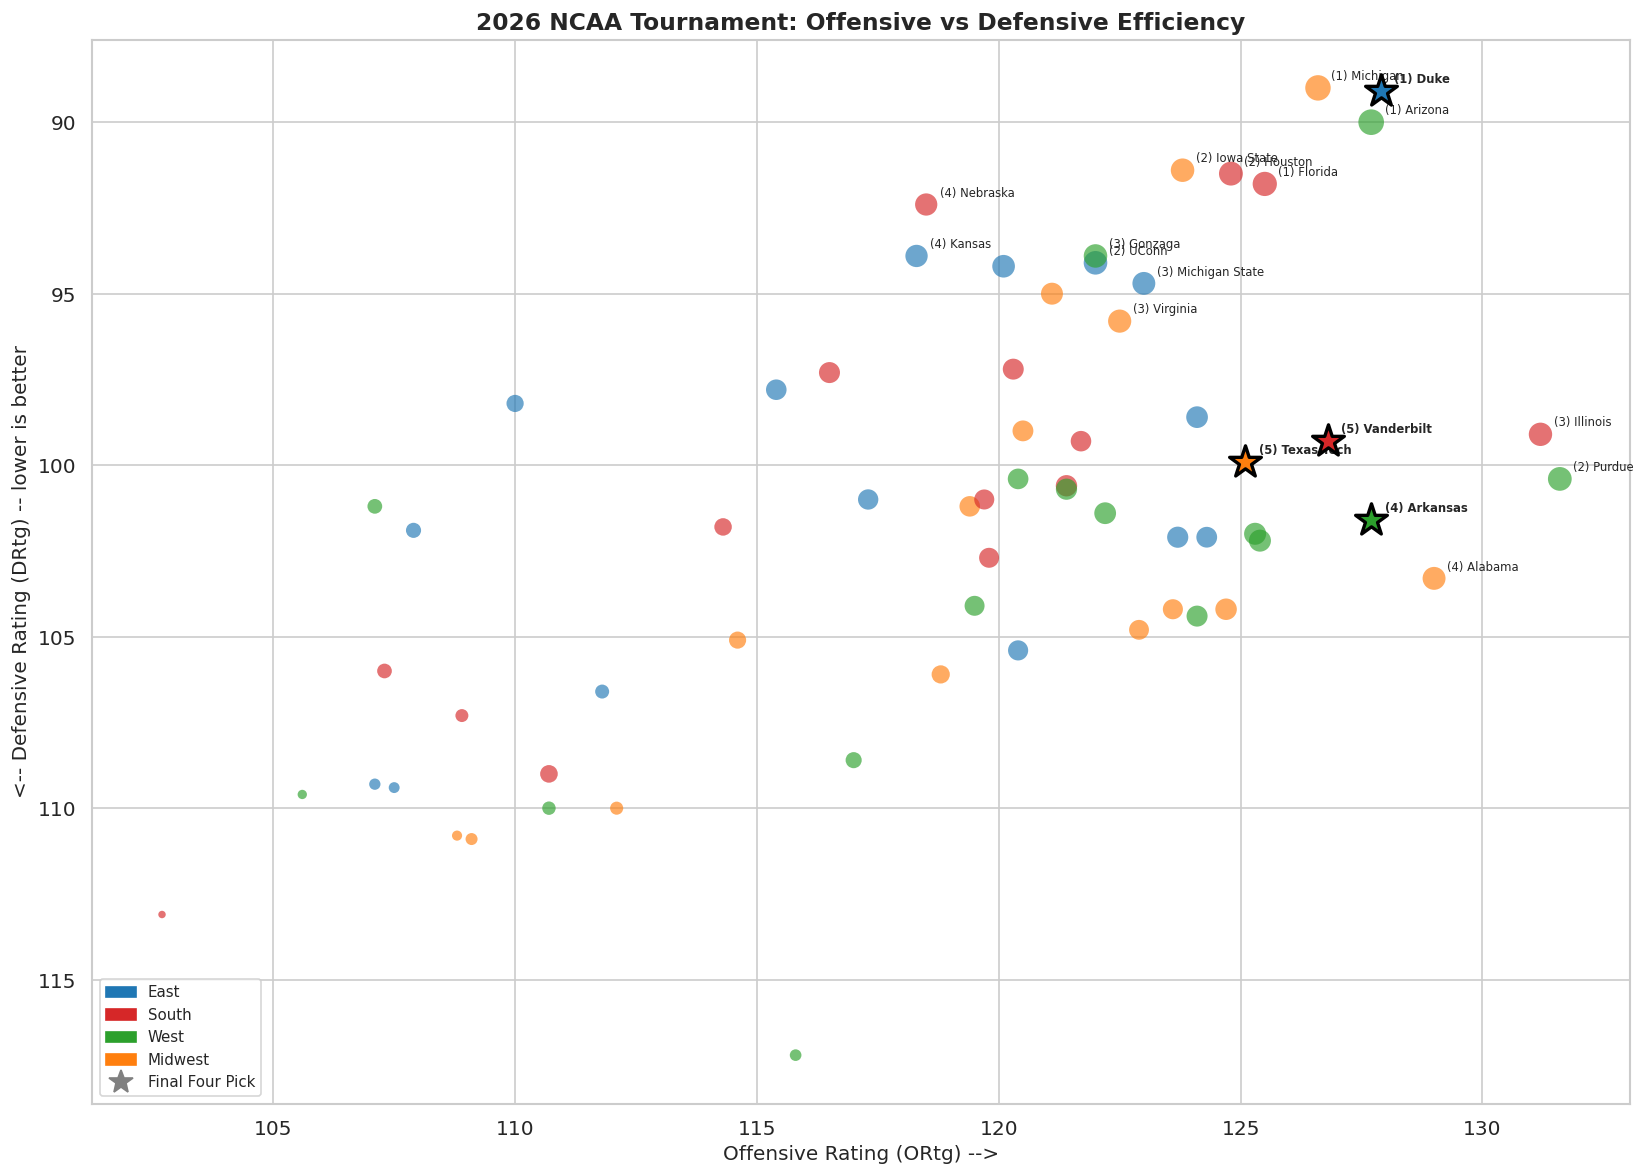

In [8]:
fig, ax = plt.subplots(figsize=(14, 10))

for _, row in df.iterrows():
    color = REGION_COLORS[row['Region']]
    is_ff = row['StdName'] in FINAL_FOUR
    size = 400 if is_ff else max(20, row['Composite'] * 2.5)
    marker = '*' if is_ff else 'o'
    ax.scatter(row['ORtg'], row['DRtg'], c=color, s=size, alpha=1.0 if is_ff else 0.65,
              marker=marker, edgecolors='black' if is_ff else 'none',
              linewidths=2 if is_ff else 0, zorder=10 if is_ff else 3)

# Label seeds 1-4 and Final Four picks
for _, row in df.iterrows():
    if row['Seed'] <= 4 or row['StdName'] in FINAL_FOUR:
        weight = 'bold' if row['StdName'] in FINAL_FOUR else 'normal'
        ax.annotate(f"({int(row['Seed'])}) {row['StdName']}", (row['ORtg'], row['DRtg']),
                   textcoords='offset points', xytext=(8, 5), fontsize=7, fontweight=weight)

ax.set_xlabel('Offensive Rating (ORtg) -->', fontsize=12)
ax.set_ylabel('<-- Defensive Rating (DRtg) -- lower is better', fontsize=12)
ax.invert_yaxis()
ax.set_title('2026 NCAA Tournament: Offensive vs Defensive Efficiency', fontsize=14, fontweight='bold')

handles = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
handles.append(Line2D([0], [0], marker='*', color='gray', markersize=15, linestyle='None', label='Final Four Pick'))
ax.legend(handles=handles, loc='lower left', fontsize=9)
plt.tight_layout()
plt.show()

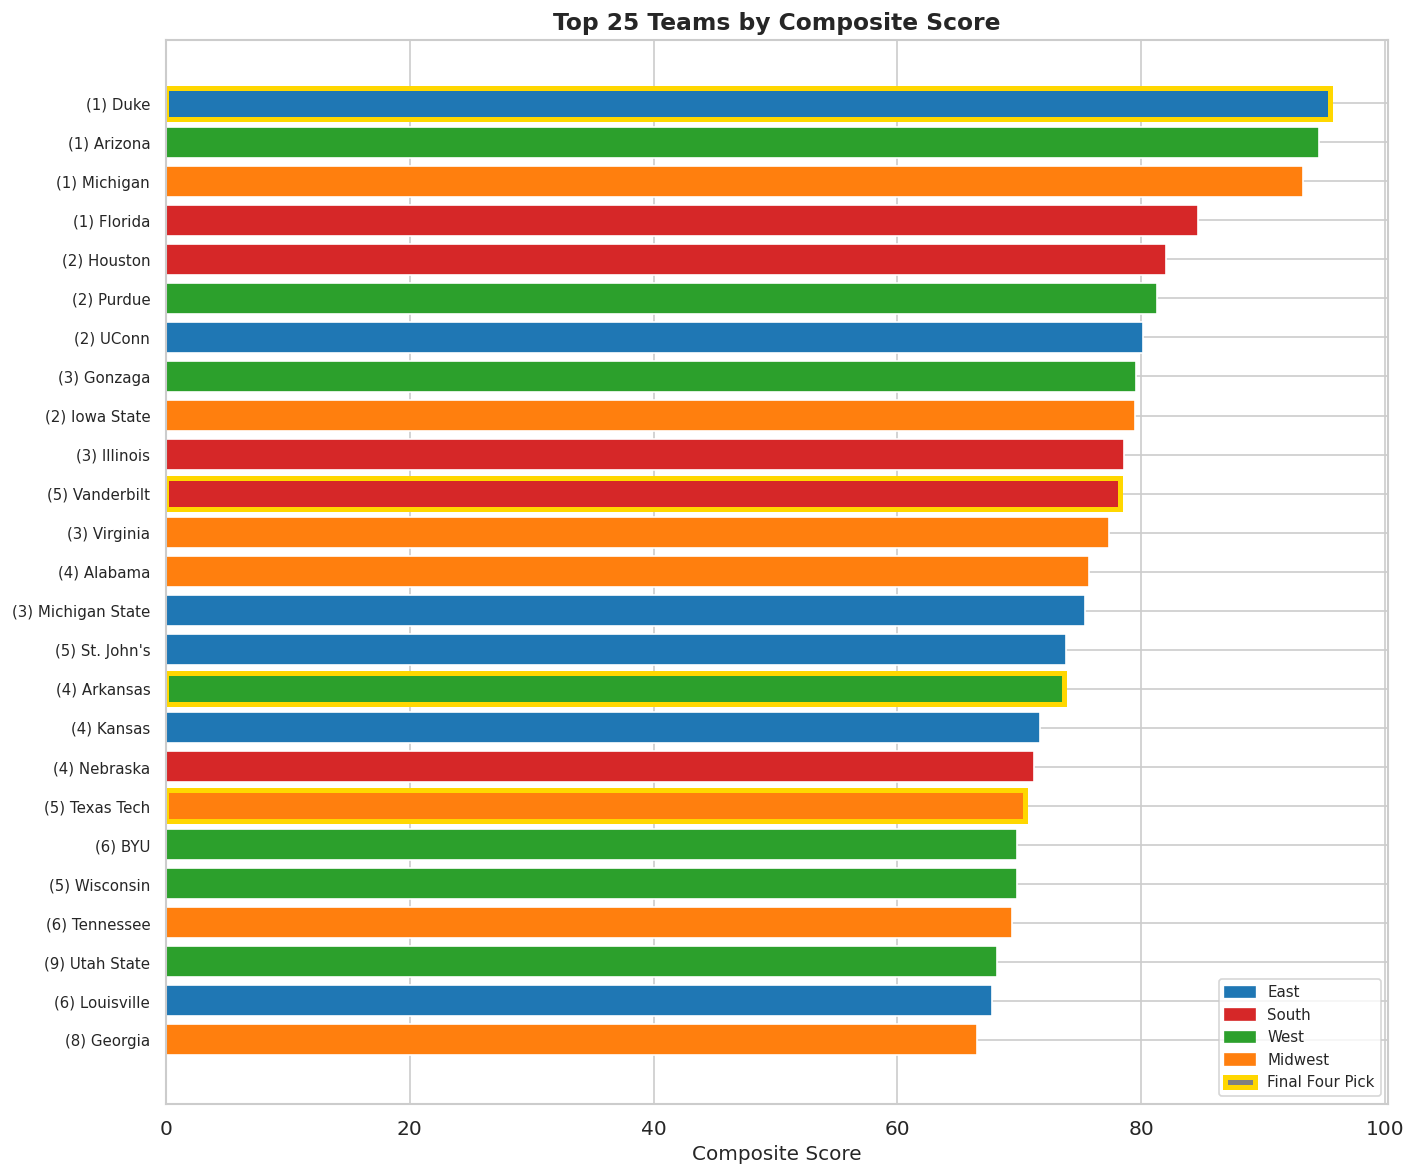

In [9]:
top25 = df.nlargest(25, 'Composite').sort_values('Composite')
fig, ax = plt.subplots(figsize=(12, 10))

colors = [REGION_COLORS[r] for r in top25['Region']]
bars = ax.barh(range(len(top25)), top25['Composite'], color=colors, edgecolor='white')

for i, (_, row) in enumerate(top25.iterrows()):
    if row['StdName'] in FINAL_FOUR:
        bars[i].set_edgecolor('gold')
        bars[i].set_linewidth(3)

ax.set_yticks(range(len(top25)))
ax.set_yticklabels([f"({int(r['Seed'])}) {r['StdName']}" for _, r in top25.iterrows()], fontsize=9)
ax.set_xlabel('Composite Score', fontsize=12)
ax.set_title('Top 25 Teams by Composite Score', fontsize=14, fontweight='bold')

handles = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
handles.append(mpatches.Patch(facecolor='gray', edgecolor='gold', linewidth=3, label='Final Four Pick'))
ax.legend(handles=handles, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [10]:
from IPython.display import display, HTML

for region in ['East', 'South', 'West', 'Midwest']:
    region_df = df[df['Region'] == region].nlargest(6, 'Composite')

    cols = ['Seed', 'StdName', 'Composite', 'Rk', 'NetRtg', 'ORtg', 'DRtg', 'NET_Rank', 'FF_Prob']
    if has_quad and 'Q1_W' in df.columns:
        cols.insert(7, 'Q1_W')
        cols.insert(8, 'Q1_L')

    tbl = region_df[cols].copy()
    rename_map = {'StdName': 'Team', 'Rk': 'KP#', 'NET_Rank': 'NET#', 'FF_Prob': 'FF%'}
    tbl = tbl.rename(columns=rename_map)

    tbl['FF%'] = tbl['FF%'].apply(lambda x: f'{x:.1%}')
    tbl['Composite'] = tbl['Composite'].round(1)
    tbl['NET#'] = tbl['NET#'].astype(int)
    if 'Q1_W' in tbl.columns and 'Q1_L' in tbl.columns:
        tbl['Q1'] = tbl.apply(lambda r: f"{int(r['Q1_W'])}-{int(r['Q1_L'])}" if pd.notna(r['Q1_W']) else '-', axis=1)
        tbl = tbl.drop(columns=['Q1_W', 'Q1_L'])
    tbl = tbl.reset_index(drop=True)

    def highlight_ff(row):
        if row['Team'] in FINAL_FOUR:
            return ['background-color: #ffffcc; font-weight: bold'] * len(row)
        return [''] * len(row)

    color = REGION_COLORS[region]
    styled = (tbl.style
              .apply(highlight_ff, axis=1)
              .set_caption(f'{region} Region')
              .set_properties(**{'text-align': 'center'})
              .set_table_styles([{'selector': 'caption',
                                  'props': [('font-size', '14px'), ('font-weight', 'bold'),
                                            ('color', color)]}]))
    display(styled)
    print()

,Seed,Team,Composite,KP#,NetRtg,ORtg,DRtg,NET#,FF%,Q1
0,1,Duke,95.500000,1,38.900000,127.900000,89.100000,1,54.6%,16-2
1,2,UConn,80.200000,11,27.850000,122.000000,94.100000,11,12.8%,8-3
2,3,Michigan State,75.400000,9,28.300000,123.000000,94.700000,9,11.8%,5-6
3,5,St. John's,73.900000,17,25.890000,120.100000,94.200000,17,5.9%,5-5
4,4,Kansas,71.700000,21,24.410000,118.300000,93.900000,21,5.1%,8-8
5,6,Louisville,67.700000,19,25.420000,124.100000,98.600000,19,4.9%,3-10


,Seed,Team,Composite,KP#,NetRtg,ORtg,DRtg,NET#,FF%,Q1
0,1,Florida,84.600000,4,33.780000,125.500000,91.800000,4,30.3%,8-5
1,2,Houston,82.100000,5,33.390000,124.800000,91.500000,5,26.0%,7-6
2,3,Illinois,78.600000,7,32.090000,131.200000,99.100000,7,22.3%,6-8
3,5,Vanderbilt,78.300000,12,27.500000,126.800000,99.300000,12,8.2%,8-5
4,4,Nebraska,71.200000,14,26.150000,118.500000,92.400000,14,7.2%,4-6
5,6,North Carolina,65.700000,29,20.830000,121.400000,100.600000,29,1.2%,6-8


,Seed,Team,Composite,KP#,NetRtg,ORtg,DRtg,NET#,FF%,Q1
0,1,Arizona,94.600000,2,37.620000,127.700000,90.000000,2,48.9%,16-2
1,2,Purdue,81.300000,8,31.190000,131.600000,100.400000,8,21.7%,8-7
2,3,Gonzaga,79.600000,10,28.100000,122.000000,93.900000,10,11.3%,8-2
3,4,Arkansas,73.700000,15,26.040000,127.700000,101.600000,15,7.4%,5-7
4,6,BYU,69.900000,23,23.210000,125.400000,102.200000,23,2.6%,7-8
5,5,Wisconsin,69.800000,22,23.380000,125.300000,102.000000,22,3.8%,5-6


,Seed,Team,Composite,KP#,NetRtg,ORtg,DRtg,NET#,FF%,Q1
0,1,Michigan,93.300000,3,37.580000,126.600000,89.000000,3,47.8%,13-3
1,2,Iowa State,79.500000,6,32.380000,123.800000,91.400000,6,24.1%,6-6
2,3,Virginia,77.400000,13,26.710000,122.500000,95.800000,13,8.2%,8-4
3,4,Alabama,75.700000,18,25.700000,129.000000,103.300000,18,5.9%,6-6
4,5,Texas Tech,70.500000,20,25.200000,125.100000,99.900000,20,4.9%,5-9
5,6,Tennessee,69.400000,16,26.020000,121.100000,95.000000,16,4.4%,5-9


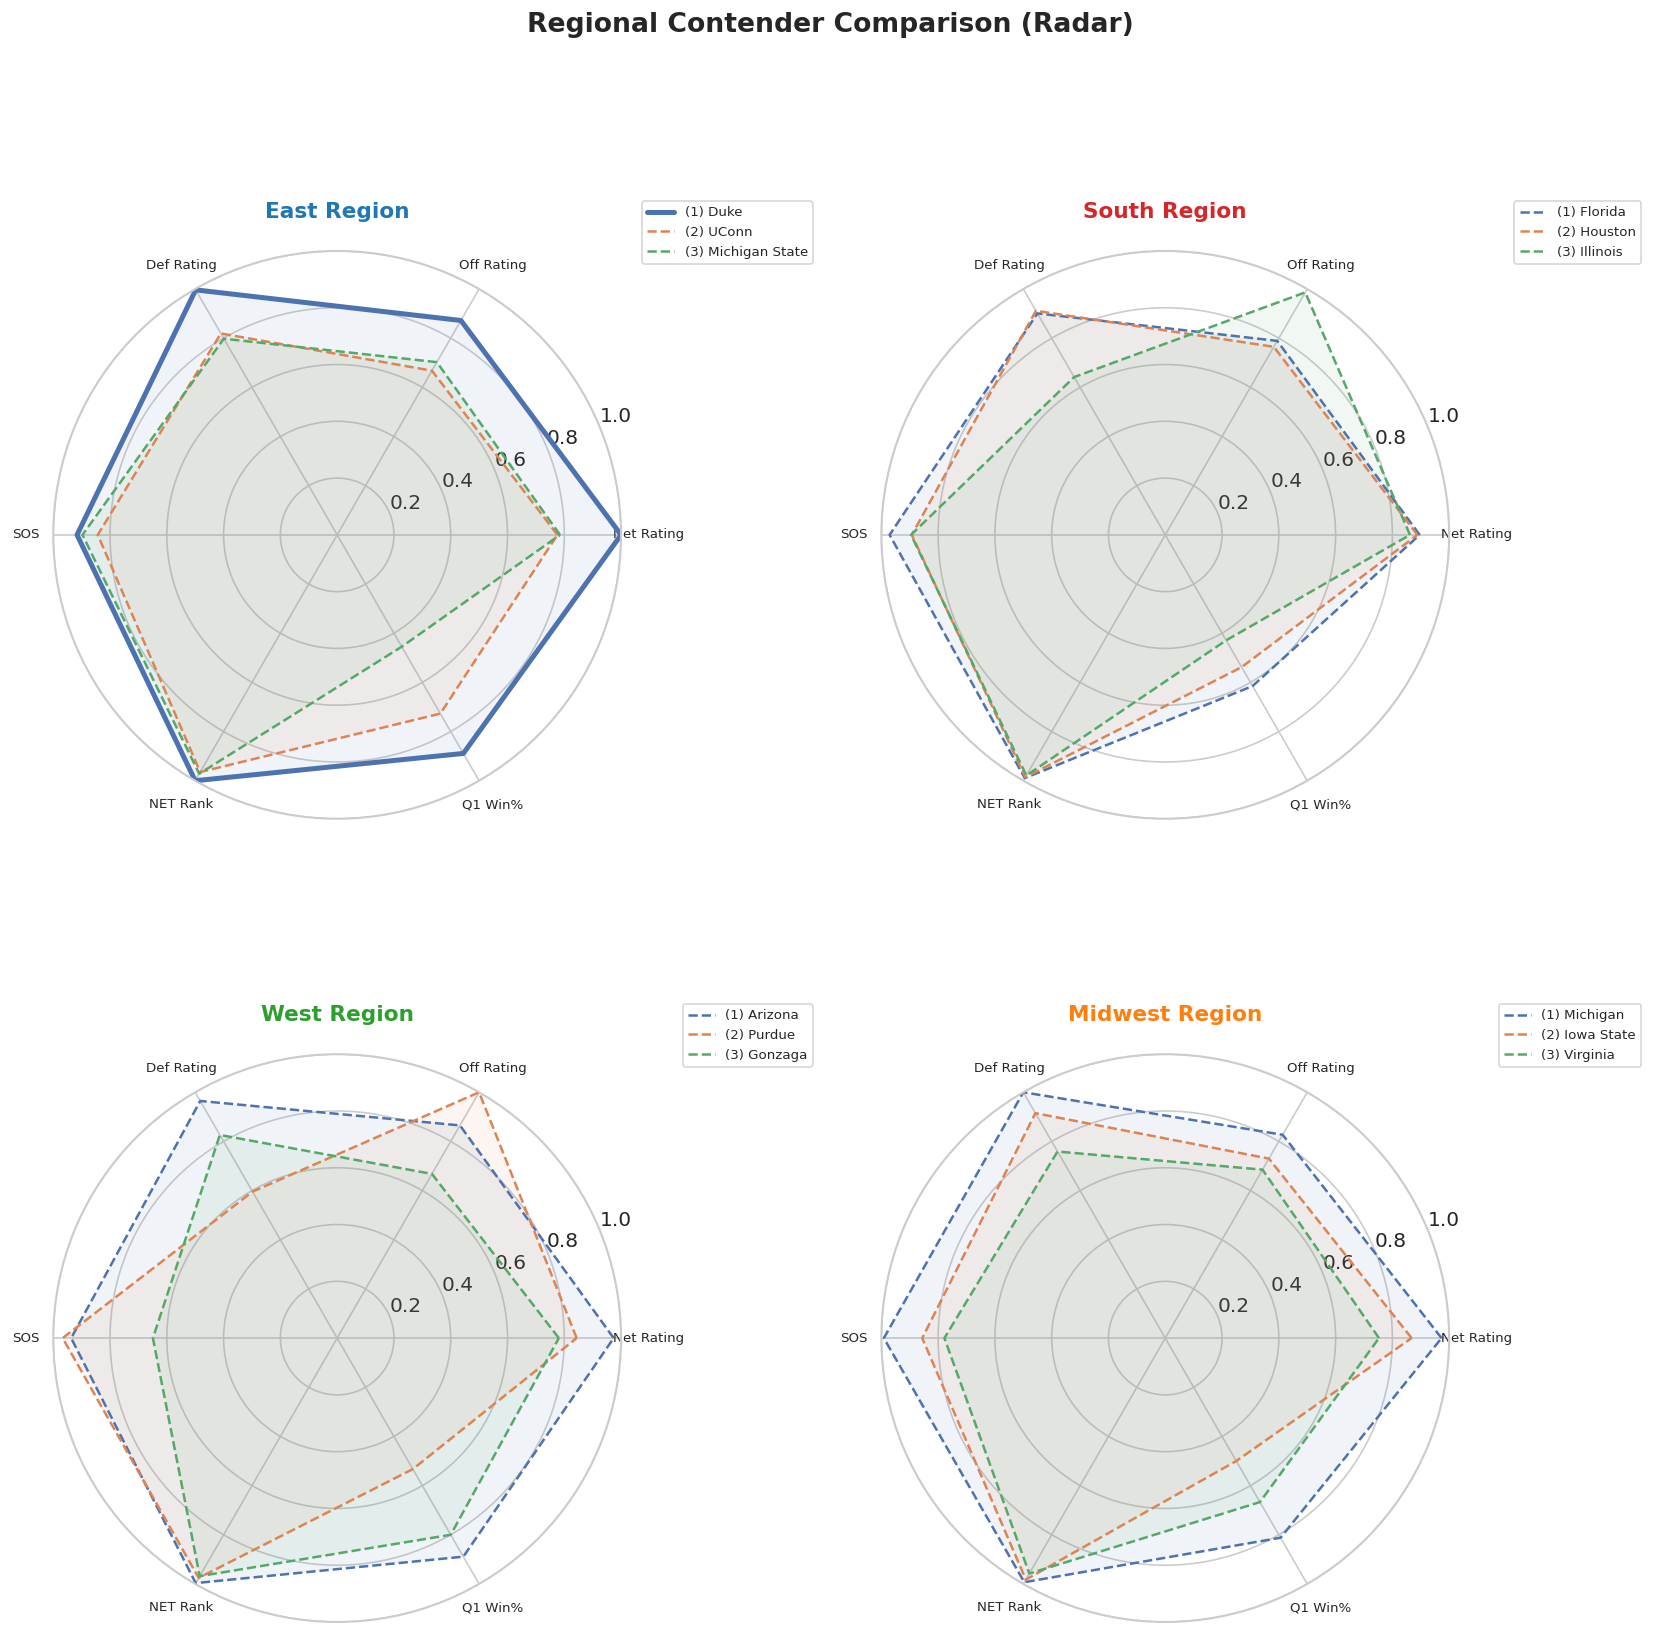

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 14), subplot_kw=dict(polar=True))

radar_metrics = ['n_NetRtg', 'n_ORtg', 'n_DRtg', 'n_SOS', 'n_NET']
radar_labels = ['Net Rating', 'Off Rating', 'Def Rating', 'SOS', 'NET Rank']

if has_quad and 'n_Q1' in df.columns:
    radar_metrics.append('n_Q1')
    radar_labels.append('Q1 Win%')

n_met = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, n_met, endpoint=False).tolist()
angles += angles[:1]

for ax, region in zip(axes.flat, ['East', 'South', 'West', 'Midwest']):
    region_top = df[df['Region'] == region].nlargest(3, 'Composite')

    for _, row in region_top.iterrows():
        values = [row[m] / 100 for m in radar_metrics]
        values += values[:1]
        is_ff = row['StdName'] in FINAL_FOUR
        label = f"({int(row['Seed'])}) {row['StdName']}"
        lw = 3 if is_ff else 1.5
        ls = '-' if is_ff else '--'
        ax.plot(angles, values, linewidth=lw, linestyle=ls, label=label)
        ax.fill(angles, values, alpha=0.08)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, size=8)
    ax.set_ylim(0, 1)
    ax.set_title(f'{region} Region', size=13, fontweight='bold',
                color=REGION_COLORS[region], pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8)

plt.suptitle('Regional Contender Comparison (Radar)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

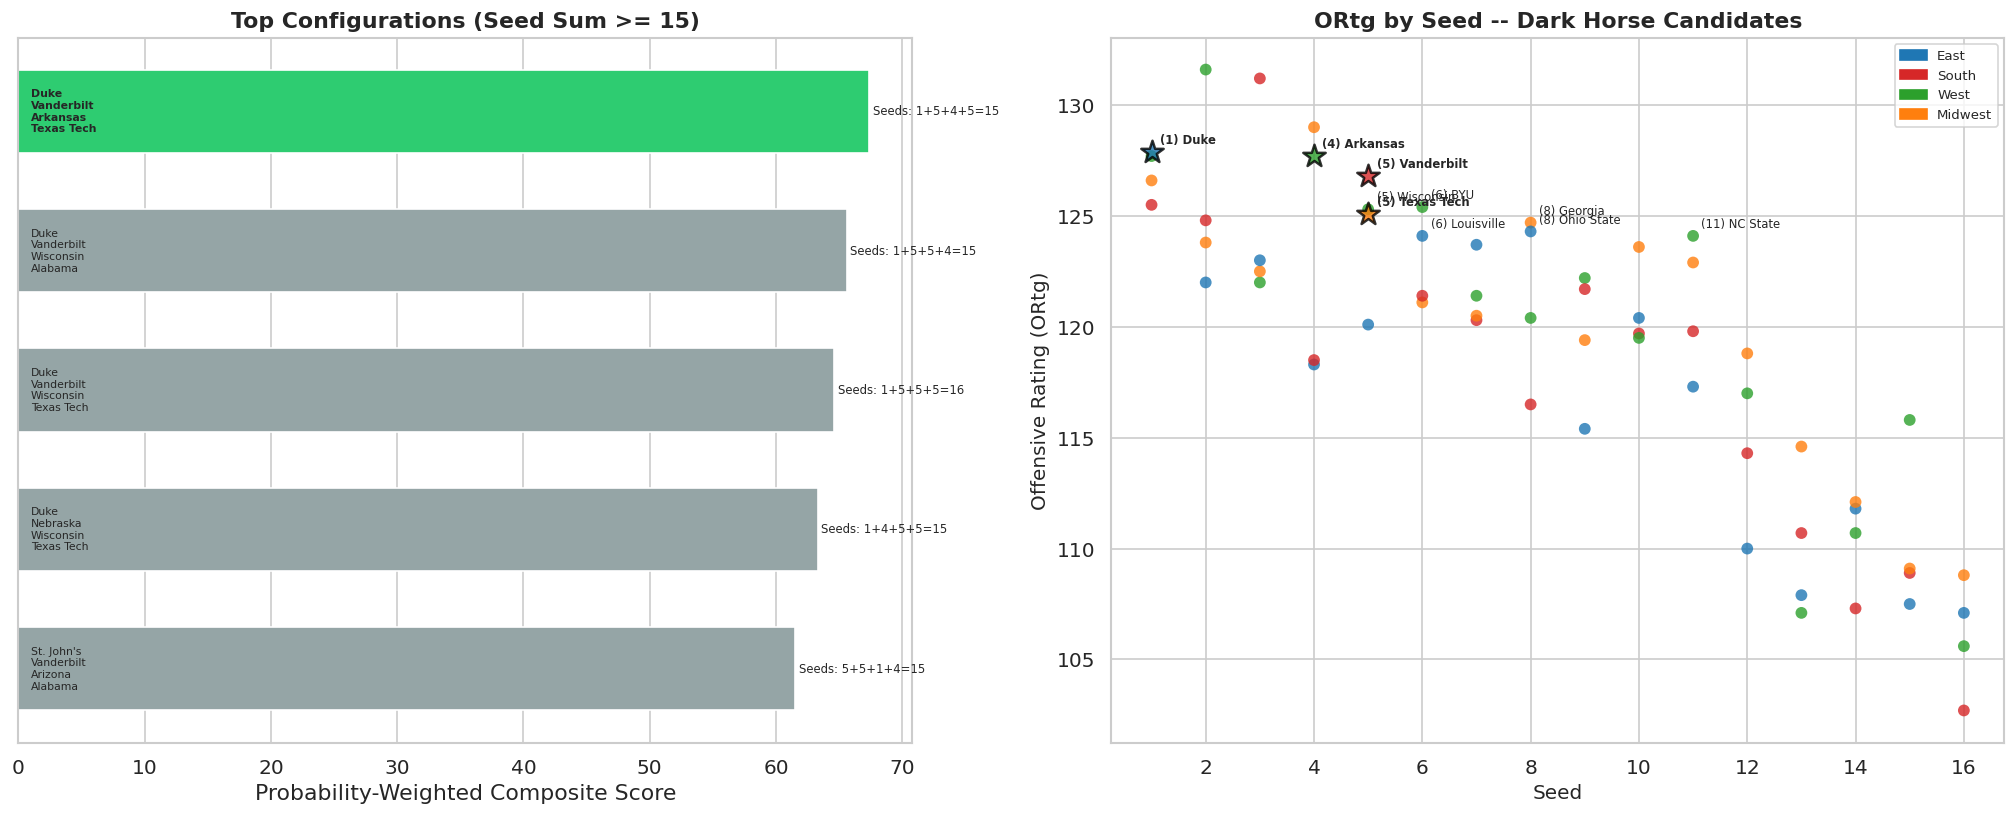

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 7))

# --- Left: Seed Constraint Configurations ---
top_cfgs = configs_df.head(5).reset_index(drop=True)
bar_colors = ['#2ecc71' if i == 0 else '#95a5a6' for i in range(len(top_cfgs))]

for i, (_, cfg) in enumerate(top_cfgs.iterrows()):
    teams_label = f"{cfg['East']}\n{cfg['South']}\n{cfg['West']}\n{cfg['Midwest']}"
    ax1.barh(i, cfg['Weighted_Score'], color=bar_colors[i], edgecolor='white', height=0.6)
    ax1.text(cfg['Weighted_Score'] + 0.3, i, f"Seeds: {cfg['Seeds']}", va='center', fontsize=7)
    ax1.text(1, i, teams_label, va='center', fontsize=6.5,
             fontweight='bold' if i == 0 else 'normal')

ax1.set_xlabel('Probability-Weighted Composite Score')
ax1.set_title('Top Configurations (Seed Sum >= 15)', fontweight='bold')
ax1.set_yticks([])
ax1.invert_yaxis()

# --- Right: ORtg vs Seed ---
for _, row in df.iterrows():
    color = REGION_COLORS[row['Region']]
    is_ff = row['StdName'] in FINAL_FOUR
    marker = '*' if is_ff else 'o'
    size = 200 if is_ff else 50
    ax2.scatter(row['Seed'], row['ORtg'], c=color, s=size, marker=marker,
               edgecolors='black' if is_ff else 'none',
               linewidths=1.5 if is_ff else 0, alpha=0.8, zorder=10 if is_ff else 3)

# Label FF picks + high-ORtg upsets
ortg_q75 = df['ORtg'].quantile(0.75)
for _, row in df.iterrows():
    if row['StdName'] in FINAL_FOUR or (row['Seed'] >= 5 and row['ORtg'] >= ortg_q75):
        ax2.annotate(f"({int(row['Seed'])}) {row['StdName']}", (row['Seed'], row['ORtg']),
                    textcoords='offset points', xytext=(5, 5), fontsize=7,
                    fontweight='bold' if row['StdName'] in FINAL_FOUR else 'normal')

ax2.set_xlabel('Seed', fontsize=12)
ax2.set_ylabel('Offensive Rating (ORtg)', fontsize=12)
ax2.set_title('ORtg by Seed -- Dark Horse Candidates', fontweight='bold')
handles = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
ax2.legend(handles=handles, fontsize=8)

plt.tight_layout()
plt.show()

## 9. Essay Bullet Points & Summary

Per-pick statistical breakdown and two essay draft structures (per-team paragraphs & cohesive narrative).

In [13]:
print('=' * 85)
print('FINAL FOUR PICKS -- DETAILED BREAKDOWN')
print('=' * 85)

for team_name in FINAL_FOUR:
    row = df[df['StdName'] == team_name].iloc[0]
    region = row['Region']
    seed = int(row['Seed'])
    pick_type = 'Chalk' if seed <= 2 else ('Dark Horse' if seed >= 5 else 'Moderate upset')

    print(f'\n--- ({seed}) {team_name} -- {region} Region [{pick_type}] ---')
    print(f'  KenPom Rank: #{int(row["Rk"])}  |  NET Rank: #{int(row["NET_Rank"])}')
    print(f'  ORtg: {row["ORtg"]:.1f} (#{row["ORtg_Rank"]} in field)  |  DRtg: {row["DRtg"]:.1f} (#{row["DRtg_Rank"]} in field)')
    print(f'  NetRtg: {row["NetRtg"]:.2f}  |  SOS: {row["SOS_NetRtg"]:.2f}')
    if has_quad and 'Q1_W' in df.columns and pd.notna(row.get('Q1_W')):
        print(f'  Q1 Record: {int(row["Q1_W"])}-{int(row["Q1_L"])} ({row["Q1_WinPct"]:.1%})')
    print(f'  Final Four Probability: {row["FF_Prob"]:.1%}')
    print(f'  Composite Score: {row["Composite"]:.1f} (#{int(row["CompRank"])} in field)')

seed_sum = sum(FINAL_FOUR_SEEDS.values())
print(f'\n{"=" * 85}')
seeds_str = ' + '.join(str(FINAL_FOUR_SEEDS[t]) for t in FINAL_FOUR)
print(f'SEED SUM: {seeds_str} = {seed_sum}')
print(f'{"=" * 85}')

# --- Thesis ---
print('\n\nTHESIS STATEMENT:')
print('My Final Four is built on a composite model weighing offensive efficiency,')
print('defensive quality, schedule strength, and NET rankings -- optimized under')
print(f'the seed-sum constraint (>= 15) via {N_SIMS:,}-iteration Monte Carlo bracket simulation.')

# --- Draft 1: Per-team paragraphs ---
print('\n\n' + '=' * 85)
print('ESSAY DRAFT 1: Per-Team Paragraphs (~200 words)')
print('=' * 85 + '\n')

for team_name in FINAL_FOUR:
    row = df[df['StdName'] == team_name].iloc[0]
    seed = int(row['Seed'])
    region = row['Region']
    para = (f'{team_name} ({seed}-seed, {region}): Ranked #{int(row["Rk"])} in KenPom '
            f'with an offensive rating of {row["ORtg"]:.1f} (#{row["ORtg_Rank"]} in the tournament field), '
            f'{team_name} {"is a dominant force" if seed <= 2 else "is a data-backed upset pick"}. '
            f'Their net efficiency of {row["NetRtg"]:.1f} and strength of schedule ({row["SOS_NetRtg"]:.1f}) '
            f'confirm they have been tested against elite competition. '
            f'My simulation gives them a {row["FF_Prob"]:.0%} chance of reaching the Final Four.')
    if team_name == 'Duke':
        para += (' One caveat: starting point guard Caleb Foster is out with a right foot fracture '
                 'suffered March 7. Cayden Boozer has stepped into a larger role and performed well '
                 'through the ACC Tournament, but these efficiency numbers reflect a full-strength roster '
                 '-- making Duke my highest-upside but also highest-variance pick.')
    print(para + '\n')

# --- Draft 2: Cohesive narrative ---
print('\n' + '=' * 85)
print('ESSAY DRAFT 2: Cohesive Narrative (~200 words)')
print('=' * 85 + '\n')

chalk = [t for t in FINAL_FOUR if FINAL_FOUR_SEEDS[t] <= 2]
moderate = [t for t in FINAL_FOUR if 3 <= FINAL_FOUR_SEEDS[t] <= 4]
dark_horses = [t for t in FINAL_FOUR if FINAL_FOUR_SEEDS[t] >= 5]

parts = []
parts.append('My Final Four selections are driven by a composite analytical model that '
             'weighs KenPom efficiency ratings, NET rankings, strength of schedule, '
             'and offensive performance -- the metric historically most predictive of tournament success.')

if chalk:
    chalk_str = ' and '.join(chalk)
    parts.append(f'{chalk_str} {"anchors" if len(chalk) == 1 else "anchor"} my bracket '
                 f'as {"a top-tier squad" if len(chalk) == 1 else "top-tier squads"} with '
                 f'dominant efficiency profiles and favorable paths to the Final Four.')
    if 'Duke' in chalk:
        parts.append('A key risk factor: Duke will be without starting point guard Caleb Foster '
                     '(right foot fracture) for likely the entire tournament. '
                     'While Cayden Boozer has filled in capably, my model reflects full-strength '
                     'season numbers, so Duke carries more variance than the raw composite suggests.')

if moderate:
    for t in moderate:
        r = df[df['StdName'] == t].iloc[0]
        parts.append(f'{t} ({int(r["Seed"])}-seed) is a calculated moderate upset: '
                     f'ranked #{int(r["Rk"])} in KenPom with a {r["ORtg"]:.1f} offensive rating '
                     f'(#{r["ORtg_Rank"]} in the field), their efficiency metrics suggest '
                     f'they are significantly underseeded and primed for a deep run.')

if dark_horses:
    for t in dark_horses:
        r = df[df['StdName'] == t].iloc[0]
        parts.append(f'{t} ({int(r["Seed"])}-seed) is a data-driven dark horse: '
                     f'ranked #{int(r["Rk"])} in KenPom with a net rating of {r["NetRtg"]:.1f} '
                     f'and strength of schedule of {r["SOS_NetRtg"]:.1f}, they outperform '
                     f'their seed in every advanced metric.')

parts.append(f'With a seed sum of {seed_sum}, this configuration satisfies the constraint '
             f'while maximizing composite quality. Each pick was validated through a '
             f'{N_SIMS:,}-iteration Monte Carlo simulation that accounts for bracket path '
             f'difficulty, matchup variance, and the inherent unpredictability that makes '
             f'March Madness compelling.')

narrative = ' '.join(parts)
words = narrative.split()
# Trim to ~200 words
if len(words) > 210:
    narrative = ' '.join(words[:200]) + '...'
    words = words[:200]
print(narrative)
print(f'\n(Word count: {len(words)})')

FINAL FOUR PICKS -- DETAILED BREAKDOWN

--- (1) Duke -- East Region [Chalk] ---
  KenPom Rank: #1  |  NET Rank: #1
  ORtg: 127.9 (#4 in field)  |  DRtg: 89.1 (#2 in field)
  NetRtg: 38.90  |  SOS: 14.29
  Q1 Record: 16-2 (88.9%)
  Final Four Probability: 54.6%
  Composite Score: 95.5 (#1 in field)

--- (5) Vanderbilt -- South Region [Dark Horse] ---
  KenPom Rank: #12  |  NET Rank: #12
  ORtg: 126.8 (#7 in field)  |  DRtg: 99.3 (#22 in field)
  NetRtg: 27.50  |  SOS: 14.56
  Q1 Record: 8-5 (61.5%)
  Final Four Probability: 8.2%
  Composite Score: 78.3 (#11 in field)

--- (4) Arkansas -- West Region [Moderate upset] ---
  KenPom Rank: #15  |  NET Rank: #15
  ORtg: 127.7 (#5 in field)  |  DRtg: 101.6 (#34 in field)
  NetRtg: 26.04  |  SOS: 14.96
  Q1 Record: 5-7 (41.7%)
  Final Four Probability: 7.4%
  Composite Score: 73.7 (#16 in field)

--- (5) Texas Tech -- Midwest Region [Dark Horse] ---
  KenPom Rank: #20  |  NET Rank: #20
  ORtg: 125.1 (#12 in field)  |  DRtg: 99.9 (#24 in field)
